# Week 42, Monday: from backpropagation to differential equations

This notebook contains the code behind every figure and number in the Monday lecture (`week42monday_lecture_v2.pdf`). The sections follow the slides:

1. **Backpropagation**: the four equations in code, checked against `jax.grad`
2. **Activation functions and initialisation**
3. **Output activation and cost function**: why they come in pairs
4. **Universal approximation**: ReLU units are kinks
5. **Neural networks for differential equations**: the equation as the cost, activation functions, boundary conditions, soft constraints (PINNs) and an inverse problem

Run the cells from top to bottom. Sections 1–4 use only `numpy` (training on MNIST takes about a minute). Section 5 uses `jax` for the derivatives.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)     # double precision, so that gradient checks agree to ~1e-15
import jax.numpy as jnp

BLUE, RED, GREEN, GREY = "#004488", "#BB5566", "#228833", "#777777"
plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=4, suppress=True)

SAVE_FIGURES = False          # True: also write the slide figures to figures/v2_*.png


def show(fig, name):
    if SAVE_FIGURES:
        fig.savefig(os.path.join("figures", name), dpi=200, bbox_inches="tight")
    plt.show()

## 1. Backpropagation

For one sample, with $z^l = W^l a^{l-1} + b^l$ and $a^l = f(z^l)$, the lecture derived the four equations

$$
\delta^L = f'(z^L)\circ\frac{\partial C}{\partial a^L},\qquad
\delta^l = \big((W^{l+1})^T\delta^{l+1}\big)\circ f'(z^l),\qquad
\frac{\partial C}{\partial b^l} = \delta^l,\qquad
\frac{\partial C}{\partial W^l} = \delta^l\,(a^{l-1})^T .
$$

**In code we process many samples at once**, stacked as the *rows* of a matrix: $Z^l = A^{l-1}W^l + b^l$, with $W^l$ of shape (inputs, outputs). These are the same equations, transposed:

$$
\Delta^l = \big(\Delta^{l+1}(W^{l+1})^T\big)\circ f'(Z^l),\qquad
\frac{\partial C}{\partial W^l} = (A^{l-1})^T\Delta^l,\qquad
\frac{\partial C}{\partial b^l} = \sum_{\text{rows}}\Delta^l .
$$

The output layer uses one of three *output activations*, each with its own cost (Section 3). For all three pairs the backward pass starts with the same line, $\Delta^L = (A^L - Y)/n$.

In [2]:
def sigmoid(z):
    e = np.exp(-np.abs(z))                       # written so that it never overflows
    return np.where(z >= 0, 1.0 / (1.0 + e), e / (1.0 + e))


def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))   # subtract the max: avoids overflow, same result
    return e / np.sum(e, axis=1, keepdims=True)


def relu(z):
    return np.maximum(0.0, z)


# hidden activations: (f, f')
ACTIVATIONS = {"sigmoid": (sigmoid, lambda z: sigmoid(z) * (1 - sigmoid(z))),
               "tanh": (np.tanh, lambda z: 1 - np.tanh(z) ** 2),
               "relu": (relu, lambda z: (z > 0).astype(float)),
               "identity": (lambda z: z, lambda z: np.ones_like(z))}

# output activations, one for each cost function
OUTPUT = {"mse": lambda z: z, "binary": sigmoid, "softmax": softmax}


def create_layers(sizes, hidden_activation="sigmoid", rng=None):
    # A list of (W, b) pairs; sizes = [784, 100, 10] gives 784 -> 100 -> 10.
    # Weights with variance 2/M for ReLU and 1/M otherwise (M = inputs per node), see Section 2.
    rng = np.random.default_rng(2026) if rng is None else rng
    layers = []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        scale = np.sqrt(2.0 / n_in) if hidden_activation == "relu" else np.sqrt(1.0 / n_in)
        layers.append((rng.normal(0.0, scale, (n_in, n_out)), np.zeros(n_out) + 0.01))
    return layers


def feed_forward(X, layers, hidden_activation="sigmoid", head="mse"):
    # Returns all z^l and a^l: the backward pass needs them.
    f, _ = ACTIVATIONS[hidden_activation]
    a, z = [X], []
    for l, (W, b) in enumerate(layers):
        z.append(a[-1] @ W + b)
        a.append(OUTPUT[head](z[-1]) if l == len(layers) - 1 else f(z[-1]))
    return z, a


def predict(X, layers, hidden_activation="sigmoid", head="mse"):
    return feed_forward(X, layers, hidden_activation, head)[1][-1]


def cost(X, Y, layers, hidden_activation="sigmoid", head="mse"):
    out = predict(X, layers, hidden_activation, head)
    if head == "mse":
        return 0.5 * np.sum((out - Y) ** 2) / len(X)
    p = np.clip(out, 1e-12, 1 - 1e-12)
    if head == "binary":
        return -np.mean(Y * np.log(p) + (1 - Y) * np.log(1 - p))
    return -np.mean(np.sum(Y * np.log(p), axis=1))


def backpropagation(X, Y, layers, hidden_activation="sigmoid", head="mse"):
    # The four equations, for all samples at once. Returns [(dW, db), ...] with the shapes of [(W, b), ...].
    _, fp = ACTIVATIONS[hidden_activation]
    z, a = feed_forward(X, layers, hidden_activation, head)
    delta = (a[-1] - Y) / len(X)                         # output layer: prediction minus target
    grads = [None] * len(layers)
    for l in range(len(layers) - 1, -1, -1):
        grads[l] = (a[l].T @ delta, np.sum(delta, axis=0))   # dC/dW = A^T Delta,  dC/db = sum of rows
        if l > 0:
            W = layers[l][0]
            delta = (delta @ W.T) * fp(z[l - 1])         # one layer back
    return grads


def train(X, Y, layers, hidden_activation="sigmoid", head="mse", gamma=0.1, epochs=100,
          batch_size=None, rng=None, X_test=None, y_test=None):
    # Plain gradient descent on minibatches (batch_size=None: all data in every step).
    rng = np.random.default_rng(2026) if rng is None else rng
    n = len(X)
    M = n if batch_size is None else batch_size
    history = {"cost": [], "test_accuracy": []}
    for epoch in range(epochs):
        order = rng.permutation(n)
        for s in range(0, n, M):
            idx = order[s:s + M]
            grads = backpropagation(X[idx], Y[idx], layers, hidden_activation, head)
            layers = [(W - gamma * dW, b - gamma * db) for (W, b), (dW, db) in zip(layers, grads)]
        history["cost"].append(cost(X, Y, layers, hidden_activation, head))
        if X_test is not None:
            pred = np.argmax(predict(X_test, layers, hidden_activation, head), axis=1)
            history["test_accuracy"].append(np.mean(pred == y_test))
    return layers, history


def one_hot(y, n_classes):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y

### Always check your gradient

A hand-written backward pass must be checked. Here we compare `backpropagation` with `jax.grad` of the same cost, for all three output heads. The output layer of `backpropagation` always starts with $\Delta^L = (A^L - Y)/n$. If the agreement below is at the level of rounding errors ($10^{-16}$), this confirms that **prediction minus target** is the correct output error for all three pairs.

In [3]:
JAX_HIDDEN = {"sigmoid": jax.nn.sigmoid, "tanh": jnp.tanh, "relu": jax.nn.relu}
JAX_OUTPUT = {"mse": lambda z: z, "binary": jax.nn.sigmoid, "softmax": lambda z: jax.nn.softmax(z, axis=1)}


def cost_jax(layers, X, Y, hidden_activation, head):
    # The same network and cost as above, written with jax.numpy so that jax.grad can differentiate it.
    a = X
    for l, (W, b) in enumerate(layers):
        z = a @ W + b
        a = JAX_OUTPUT[head](z) if l == len(layers) - 1 else JAX_HIDDEN[hidden_activation](z)
    if head == "mse":
        return 0.5 * jnp.sum((a - Y) ** 2) / len(X)
    if head == "binary":
        return -jnp.mean(Y * jnp.log(a) + (1 - Y) * jnp.log(1 - a))
    return -jnp.mean(jnp.sum(Y * jnp.log(a), axis=1))


def to_jax(layers):
    return [(jnp.asarray(W), jnp.asarray(b)) for W, b in layers]


rng = np.random.default_rng(1)
X = rng.normal(size=(8, 3))
for head, n_out, Y in (("mse", 2, rng.normal(size=(8, 2))),
                       ("binary", 1, rng.integers(0, 2, (8, 1)).astype(float)),
                       ("softmax", 3, one_hot(rng.integers(0, 3, 8), 3))):
    layers = create_layers([3, 5, 4, n_out], "tanh", rng)
    mine = backpropagation(X, Y, layers, "tanh", head)
    ref = jax.grad(cost_jax)(to_jax(layers), X, Y, "tanh", head)
    err = max(float(np.max(np.abs(np.asarray(g_ref) - g_mine)))
              for (dW, db), (rW, rb) in zip(mine, ref) for g_mine, g_ref in ((dW, rW), (db, rb)))
    print(f"{head:8s} max |backpropagation - jax.grad| = {err:.1e}")

mse      max |backpropagation - jax.grad| = 1.1e-16


binary   max |backpropagation - jax.grad| = 2.8e-17


softmax  max |backpropagation - jax.grad| = 4.2e-17


## 2. Activation functions and initialisation

The backward pass multiplies by $f'$ once per layer. The sigmoid has $f'\le 1/4$, tanh has $f'\le 1$, and ReLU has $f'=1$ for $z>0$. All three are flat somewhere: $f'\approx 0$ for large $|z|$ (sigmoid, tanh) or for $z<0$ (ReLU).

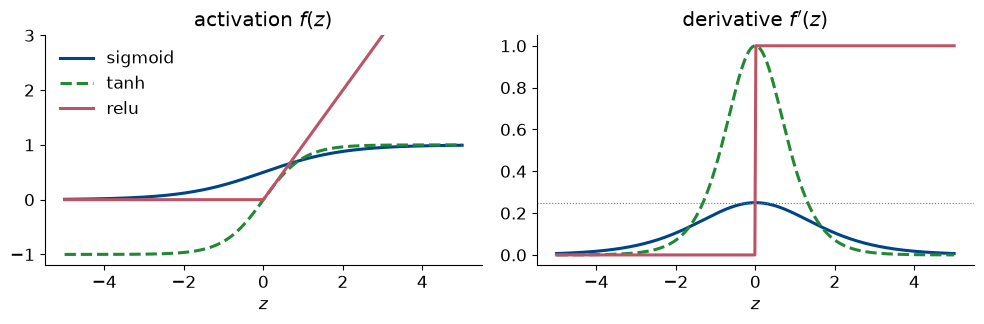

In [4]:
z = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for name, col, ls in (("sigmoid", BLUE, "-"), ("tanh", GREEN, "--"), ("relu", RED, "-")):
    f, fp = ACTIVATIONS[name]
    ax[0].plot(z, f(z), color=col, lw=2.2, ls=ls, label=name)
    ax[1].plot(z, fp(z), color=col, lw=2.2, ls=ls, label=name)
ax[0].set_ylim(-1.2, 3)
ax[0].set_title("activation $f(z)$")
ax[1].set_title("derivative $f'(z)$")
ax[1].axhline(0.25, color=GREY, lw=0.8, ls=":")
for a_ in ax:
    a_.set_xlabel("$z$")
ax[0].legend(frameon=False)
fig.tight_layout()
show(fig, "v2_activations.png")

### Initialising the weights

A node sums $M$ inputs, $z=\sum_k w_k a_k$. With independent weights of variance $\sigma_w^2$, $\operatorname{Var}(z)\approx M\sigma_w^2\,\overline{a^2}$. To keep the signal the same size in every layer we choose

$$\sigma_w^2 = 1/M \ \text{(tanh, sigmoid)},\qquad \sigma_w^2 = 2/M\ \text{(ReLU, which sets half of its inputs to zero)}.$$

This is what `create_layers` does. Below, a network with 10 hidden layers of 256 units gets random inputs, and we look at the activations and the gradients **before any training**.

tanh, $\sigma_w=1$ (too large)    : saturated units in layer 10:  87%,  |dC/dW| layer 1 / layer 10 = 3.2e+03 / 2.1e-01
tanh, $\sigma_w=0.01$ (too small) : saturated units in layer 10:   0%,  |dC/dW| layer 1 / layer 10 = 5.5e-08 / 4.8e-08


tanh, $\sigma_w^2=1/M$            : saturated units in layer 10:   0%,  |dC/dW| layer 1 / layer 10 = 2.4e-01 / 2.6e-01


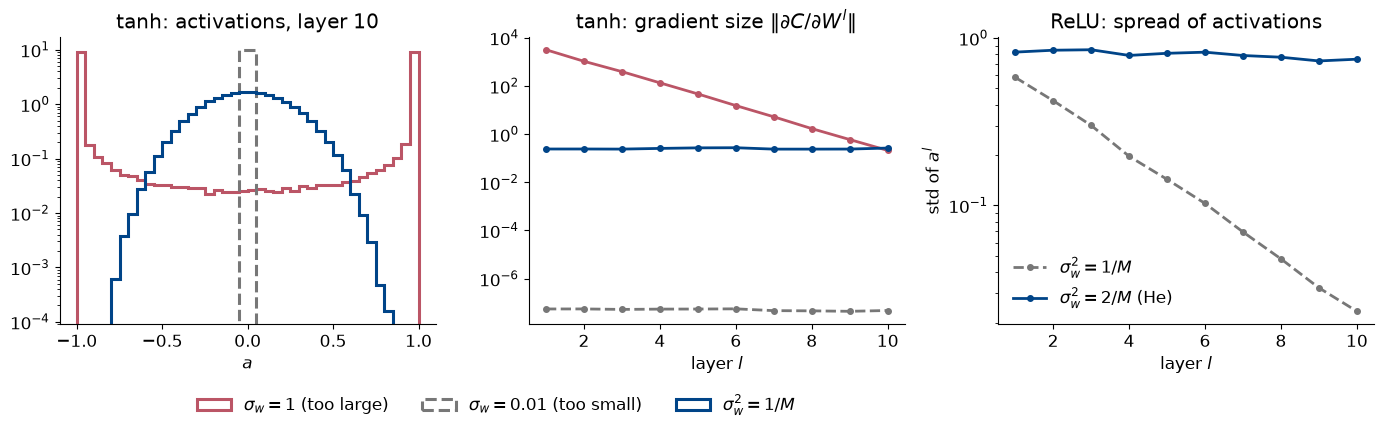

In [5]:
M, depth, n = 256, 10, 500
rng = np.random.default_rng(0)
X_init = rng.normal(size=(n, M))
Y_init = rng.normal(size=(n, 1))


def deep_network_stats(activation, sigma_w, seed=1):
    # Forward and backward pass through `depth` hidden layers of width M (no biases), linear output,
    # C = 1/2 mean (a - y)^2. Returns the activations of each hidden layer and |dC/dW^l| for each layer.
    r = np.random.default_rng(seed)
    f, fp = ACTIVATIONS[activation]
    Ws = [r.normal(0, sigma_w, (M, M)) for _ in range(depth)] + [r.normal(0, np.sqrt(1 / M), (M, 1))]
    a, zs, As = X_init, [], [X_init]
    for l, W in enumerate(Ws):
        zs.append(a @ W)
        a = f(zs[-1]) if l < depth else zs[-1]
        As.append(a)
    delta = (a - Y_init) / n
    grad_norm = []
    for l in range(depth, -1, -1):
        grad_norm.append(np.linalg.norm(As[l].T @ delta))
        if l > 0:
            delta = (delta @ Ws[l].T) * fp(zs[l - 1])
    return As[1:depth + 1], grad_norm[::-1][:depth]


tanh_cases = ((1.0, r"$\sigma_w=1$ (too large)", RED, "-"),
              (0.01, r"$\sigma_w=0.01$ (too small)", GREY, "--"),
              (np.sqrt(1 / M), r"$\sigma_w^2=1/M$", BLUE, "-"))
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
layer = np.arange(1, depth + 1)
for sigma_w, label, col, ls in tanh_cases:
    As, gn = deep_network_stats("tanh", sigma_w)
    ax[0].hist(As[-1].ravel(), bins=np.linspace(-1, 1, 41), density=True, histtype="step",
               lw=2.2, color=col, ls=ls, label=label)
    ax[1].semilogy(layer, gn, marker="o", color=col, ls=ls, lw=2, ms=4)
    print(f"tanh, {label:28s}: saturated units in layer 10: {np.mean(np.abs(As[-1]) > 0.99):4.0%},  "
          f"|dC/dW| layer 1 / layer 10 = {gn[0]:.1e} / {gn[-1]:.1e}")
ax[0].set_yscale("log")
ax[0].set_title("tanh: activations, layer 10")
ax[0].set_xlabel("$a$")
ax[1].set_title(r"tanh: gradient size $\|\partial C/\partial W^l\|$")
ax[1].set_xlabel("layer $l$")
for sigma2, label, col, ls in ((1 / M, r"$\sigma_w^2=1/M$", GREY, "--"), (2 / M, r"$\sigma_w^2=2/M$ (He)", BLUE, "-")):
    As, _ = deep_network_stats("relu", np.sqrt(sigma2))
    ax[2].semilogy(layer, [A.std() for A in As], marker="o", color=col, ls=ls, lw=2, ms=4, label=label)
ax[2].set_title("ReLU: spread of activations")
ax[2].set_xlabel("layer $l$")
ax[2].set_ylabel("std of $a^l$")
ax[2].legend(frameon=False)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", bbox_to_anchor=(0.36, -0.1), ncol=3, frameon=False)
fig.tight_layout()
show(fig, "v2_init.png")

**What to see.**
- **Too large:** the tanh units saturate at $\pm1$, and the gradients *grow* layer by layer on the way back.
- **Too small:** everything shrinks towards zero, and so do the gradients.
- **$1/M$:** the gradients are the same size in every layer.
- **ReLU:** $1/M$ lets the signal die out; $2/M$ keeps it.

*Try it:* make the network deeper (`depth = 30`), or use the sigmoid with $\sigma_w^2=1/M$.

## 3. Output activation and cost function come in pairs

| Task | Output activation | Cost (one sample) | $\delta^L$ |
|---|---|---|---|
| regression, $y\in\mathbb R$ | linear, $a=z$ | $\frac12(a-y)^2$ | $a-y$ |
| binary, $y\in\{0,1\}$ | sigmoid | $-y\ln a-(1-y)\ln(1-a)$ | $a-y$ |
| $K$ classes, one-hot $\mathbf y$ | softmax | $-\sum_k y_k\ln a_k$ | $\mathbf a-\mathbf y$ |

For these pairs, $f'$ of the output activation cancels against $\partial C/\partial a$. The gradient check in Section 1 confirmed this. What happens *without* the cancellation, with a sigmoid output and the squared error? Then $\delta^L = (a-y)\,a(1-a)$:

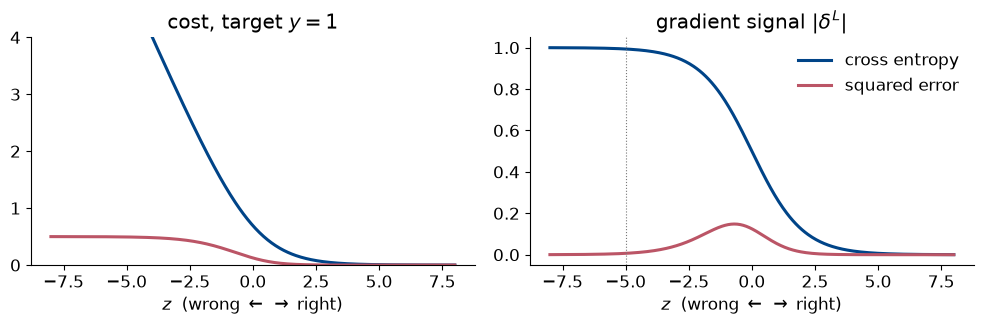

z = -5, y = 1:  a = 0.0067,  cross entropy delta = -0.993,  squared error delta = -0.0066  (ratio 150)


In [6]:
z = np.linspace(-8, 8, 400)
a = sigmoid(z)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(z, -np.log(a), color=BLUE, lw=2.2, label="cross entropy")
ax[0].plot(z, 0.5 * (a - 1) ** 2, color=RED, lw=2.2, label="squared error")
ax[0].set_ylim(0, 4)
ax[0].set_title("cost, target $y=1$")
ax[1].plot(z, np.abs(a - 1), color=BLUE, lw=2.2, label="cross entropy")
ax[1].plot(z, np.abs(a - 1) * a * (1 - a), color=RED, lw=2.2, label="squared error")
ax[1].set_title(r"gradient signal $|\delta^L|$")
ax[1].axvline(-5, color=GREY, lw=0.8, ls=":")
for a_ in ax:
    a_.set_xlabel(r"$z$  (wrong $\leftarrow$ $\rightarrow$ right)")
ax[1].legend(frameon=False)
fig.tight_layout()
show(fig, "v2_delta_heads.png")

a5 = sigmoid(-5.0)
print(f"z = -5, y = 1:  a = {a5:.4f},  cross entropy delta = {a5 - 1:.3f},  "
      f"squared error delta = {(a5 - 1) * a5 * (1 - a5):.4f}  (ratio {1 / (a5 * (1 - a5)):.0f})")

### Which image trains the network?

We train a $784$–$100$–$10$ network with ReLU hidden units, the softmax and the cross entropy on the MNIST digits: 20 epochs, minibatches of 100, $\gamma=0.1$. This takes about a minute. Then we look at the test image the network is most sure about, and the one it is least sure about.

In [7]:
def load_mnist():
    # Looks for the repository's mnist.npz first; otherwise downloads with scikit-learn (once).
    for path in ("mnist.npz", os.path.join("..", "..", "BookML", "BookPrograms",
                                           "chapter10_convolutional_networks", "mnist.npz")):
        if os.path.exists(path):
            d = np.load(path)
            X_train = d["x_train"].reshape(len(d["x_train"]), -1) / 255.0
            X_test = d["x_test"].reshape(len(d["x_test"]), -1) / 255.0
            return X_train, d["y_train"].astype(int), X_test, d["y_test"].astype(int)
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X, y = mnist.data / 255.0, mnist.target.astype(int)
    return X[:60000], y[:60000], X[60000:], y[60000:]


t0 = time.time()
X_train, y_train, X_test, y_test = load_mnist()
layers = create_layers([784, 100, 10], "relu", np.random.default_rng(2026))
layers, hist = train(X_train, one_hot(y_train, 10), layers, "relu", "softmax", gamma=0.1, epochs=20,
                     batch_size=100, X_test=X_test, y_test=y_test)
print(f"test accuracy after 20 epochs: {hist['test_accuracy'][-1]:.2%}  ({time.time() - t0:.0f} s)")

test accuracy after 20 epochs: 97.63%  (17 s)


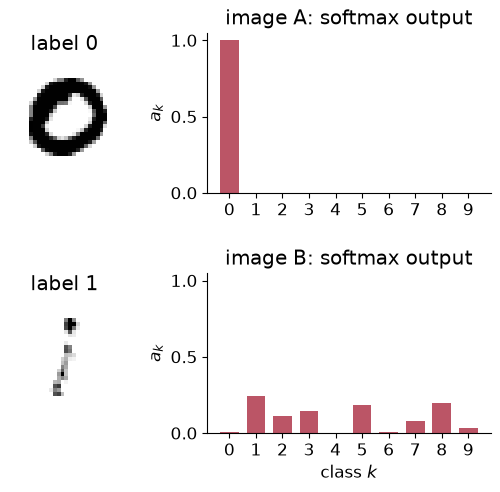

image A (label 0): delta^L = a - y = [-0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
image B (label 1): delta^L = a - y = [ 0.005 -0.76   0.115  0.141  0.     0.187  0.006  0.077  0.198  0.031]


In [8]:
P = predict(X_test, layers, "relu", "softmax")
pred, pmax = P.argmax(axis=1), P.max(axis=1)
i_A = int(np.argmax(np.where(pred == y_test, pmax, -1)))     # the most confident correct prediction
i_B = int(np.argmin(pmax))                                   # the least confident prediction

fig = plt.figure(figsize=(6.2, 5.2))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 2.6], wspace=0.45, hspace=0.5)
for row, (i, name) in enumerate(((i_A, "A"), (i_B, "B"))):
    axi = fig.add_subplot(gs[row, 0])
    axi.imshow(X_test[i].reshape(28, 28), cmap="gray_r")
    axi.set_title(f"label {y_test[i]}")
    axi.axis("off")
    axb = fig.add_subplot(gs[row, 1])
    axb.bar(np.arange(10), P[i], color=RED, width=0.7)
    axb.set_xticks(np.arange(10))
    axb.set_ylim(0, 1.05)
    axb.set_ylabel("$a_k$")
    axb.set_title(f"image {name}: softmax output")
axb.set_xlabel("class $k$")
show(fig, "v2_mnist_question.png")

for i, name in ((i_A, "A"), (i_B, "B")):
    delta = P[i] - one_hot(y_test[i:i + 1], 10)[0]
    print(f"image {name} (label {y_test[i]}): delta^L = a - y = {np.round(delta, 3)}")

For image A, $\delta^L\approx 0$: there is nothing left to learn from it. For image B, $\delta_1 = 0.24 - 1 = -0.76$, and the other classes get positive errors. The gradient raises the score of the correct class and lowers the others. The network learns most from the examples it gets wrong or is unsure about.

## 4. Universal approximation: ReLU units are kinks

One ReLU unit $v\,\mathrm{ReLU}(wx+b)$ is zero, then a straight line: it has one kink, at $x=-b/w$. Three units make a "hat", and a sum of hats can follow any continuous curve ("connect the dots"):

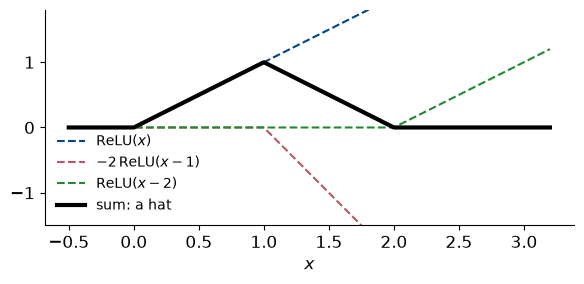

In [9]:
x = np.linspace(-0.5, 3.2, 500)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, relu(x), color=BLUE, ls="--", label=r"$\mathrm{ReLU}(x)$")
ax.plot(x, -2 * relu(x - 1), color=RED, ls="--", label=r"$-2\,\mathrm{ReLU}(x-1)$")
ax.plot(x, relu(x - 2), color=GREEN, ls="--", label=r"$\mathrm{ReLU}(x-2)$")
ax.plot(x, relu(x) - 2 * relu(x - 1) + relu(x - 2), color="k", lw=3, label="sum: a hat")
ax.set_ylim(-1.5, 1.8)
ax.set_xlabel("$x$")
ax.legend(frameon=False, fontsize=10, loc="lower left")
fig.tight_layout()
plt.show()

Training finds such a construction by itself. We fit a $1$–$50$–$1$ ReLU network to noisy data from the Runge function $1/(1+25x^2)$ (the data of Project 1): 20 000 steps of plain gradient descent. The output is piecewise linear, and we mark its kinks.

test MSE 0.0094 (the noise variance is 0.01); 50 kinks inside [-1, 1]


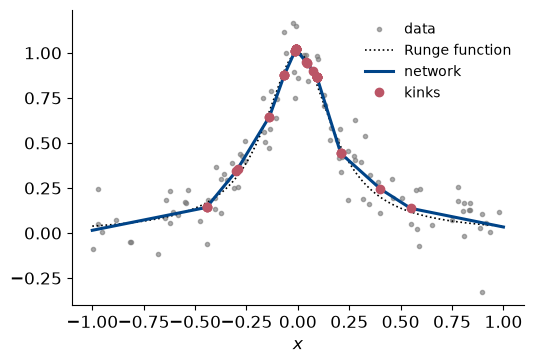

In [10]:
def runge_data(n=100, sigma=0.1, seed=2026):
    # Project 1: x uniform on [-1, 1], y = 1/(1 + 25 x^2) + noise; a training and a test set.
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1, 1, n))
    y = 1.0 / (1.0 + 25 * x ** 2) + rng.normal(0, sigma, n)
    x_test = np.sort(rng.uniform(-1, 1, n))
    y_test = 1.0 / (1.0 + 25 * x_test ** 2) + rng.normal(0, sigma, n)
    return x[:, None], y[:, None], x_test[:, None], y_test[:, None]


X, Y, Xt, Yt = runge_data()
layers = create_layers([1, 50, 1], "relu", np.random.default_rng(2026))
layers, hist = train(X, Y, layers, "relu", "mse", gamma=0.1, epochs=20000)
(W1, b1), (W2, b2) = layers
kinks = -b1 / W1[0]
kinks = np.sort(kinks[(kinks > -1) & (kinks < 1) & (np.abs(W2[:, 0] * W1[0]) > 1e-3)])
print(f"test MSE {np.mean((predict(Xt, layers, 'relu') - Yt) ** 2):.4f} (the noise variance is 0.01); "
      f"{len(kinks)} kinks inside [-1, 1]")

xx = np.linspace(-1, 1, 801)[:, None]
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.plot(X, Y, "o", color=GREY, ms=3, alpha=0.6, label="data")
ax.plot(xx, 1 / (1 + 25 * xx ** 2), color="k", lw=1.2, ls=":", label="Runge function")
ax.plot(xx, predict(xx, layers, "relu"), color=BLUE, lw=2.2, label="network")
ax.plot(kinks, predict(kinks[:, None], layers, "relu")[:, 0], "o", color=RED, ms=6, label="kinks")
ax.set_xlabel("$x$")
ax.legend(frameon=False, fontsize=10, loc="upper right")
fig.tight_layout()
show(fig, "v2_runge_kinks.png")

*Try it:* use `"identity"` as the hidden activation. What does the network fit now, and why?

## 5. Neural networks for differential equations

We want to solve, for example, $g'(x) = -\kappa g(x)$ with $g(0)=g_0$. There are no data $g(x_i)$, only the equation. The method has three ingredients:

1. A **trial solution** $g_t(x) = h(x) + B(x)\,N(x)$ that satisfies the conditions for *any* network $N$: $h$ satisfies the conditions, and $B=0$ where they are imposed.
2. The **residual**, here $r(x) = g_t'(x) + \kappa g_t(x)$, which is zero for the exact solution.
3. The **cost** $C = \frac1n\sum_i r(x_i)^2$ at *collocation points* $x_i$ that we choose ourselves.

The residual contains $g_t'$, so we need the derivative of the network with respect to its **input** $x$. Writing this by hand is tedious, so we let JAX do it. The network is the same as before, written in `jax.numpy` with a linear output.

In [11]:
JAX_ACTIVATIONS = {"tanh": jnp.tanh, "sigmoid": jax.nn.sigmoid, "relu": jax.nn.relu, "gelu": jax.nn.gelu}


def network(layers, X, activation="tanh"):
    # N(x): the forward pass with a linear output; X has one row per point (one column per input).
    f = JAX_ACTIVATIONS[activation]
    a = X
    for l, (W, b) in enumerate(layers):
        z = a @ W + b
        a = f(z) if l < len(layers) - 1 else z
    return a[:, 0]


def d_dxk(fun, k):
    # The derivative of fun(layers, X) with respect to input column k, row by row.
    # Nest it for higher derivatives: d_dxk(d_dxk(u, 0), 0) is the second derivative in x_0.
    def wrapped(layers, X):
        def one_row(xk, row):
            return fun(layers, row.at[k].set(xk)[None, :])[0]
        return jax.vmap(jax.grad(one_row))(X[:, k], X)
    return wrapped


def adam_minimise(cost_fn, params, n_iter=2000, gamma=1e-2, b1=0.9, b2=0.999, eps=1e-8, every=50, trace_fn=None):
    # Adam for any nested structure of arrays. jax.value_and_grad does the backward pass for us.
    tree = jax.tree_util

    @jax.jit
    def step(params, m, v, it):
        c, g = jax.value_and_grad(cost_fn)(params)
        m = tree.tree_map(lambda m_, g_: b1 * m_ + (1 - b1) * g_, m, g)
        v = tree.tree_map(lambda v_, g_: b2 * v_ + (1 - b2) * g_ ** 2, v, g)
        params = tree.tree_map(lambda p, m_, v_: p - gamma * (m_ / (1 - b1 ** it)) / (jnp.sqrt(v_ / (1 - b2 ** it)) + eps),
                               params, m, v)
        return params, m, v, c

    m = tree.tree_map(jnp.zeros_like, params)
    v = tree.tree_map(jnp.zeros_like, params)
    history = []
    for it in range(1, n_iter + 1):
        params, m, v, c = step(params, m, v, jnp.asarray(it, dtype=float))
        if it == 1 or it % every == 0 or it == n_iter:
            extra = tuple(np.atleast_1d(np.asarray(trace_fn(params)))) if trace_fn else ()
            history.append((it, float(c)) + extra)
    return params, np.array(history)


def solve_de(residual, sizes, X, n_iter=2000, gamma=1e-2, seed=1):
    # Minimise the mean squared residual at the collocation points X.
    layers = to_jax(create_layers(sizes, "tanh", np.random.default_rng(seed)))
    X = jnp.asarray(X)
    return adam_minimise(lambda layers: jnp.mean(residual(layers, X) ** 2), layers, n_iter=n_iter, gamma=gamma)

### Example: exponential decay

With $\kappa=2$ and $g_0=10$, the trial solution is $g_t = g_0 + x\,N(x)$, so $g_t(0)=g_0$ whatever the network does. Its derivative is $g_t' = N + xN'$, which `d_dxk` computes for us.

final cost 2.0e-03,  max error 3.1e-03  (1 s)


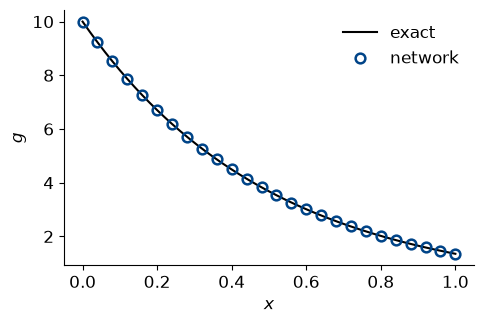

In [12]:
KAPPA, G0 = 2.0, 10.0


def trial_decay(layers, X):
    return G0 + X[:, 0] * network(layers, X)


def residual_decay(layers, X):
    return d_dxk(trial_decay, 0)(layers, X) + KAPPA * trial_decay(layers, X)


t0 = time.time()
X_col = np.linspace(0, 1, 50)[:, None]                     # 50 collocation points
layers_decay, hist = solve_de(residual_decay, [1, 40, 40, 1], X_col, n_iter=3000, gamma=2e-2)
xx = np.linspace(0, 1, 401)
g = np.asarray(trial_decay(layers_decay, jnp.asarray(xx[:, None])))
print(f"final cost {hist[-1, 1]:.1e},  max error {np.abs(g - G0 * np.exp(-KAPPA * xx)).max():.1e}  "
      f"({time.time() - t0:.0f} s)")

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(xx, G0 * np.exp(-KAPPA * xx), color="k", lw=1.5, label="exact")
ax.plot(xx[::16], g[::16], "o", color=BLUE, ms=7, mfc="none", mew=1.8, label="network")
ax.set_xlabel("$x$")
ax.set_ylabel("$g$")
ax.legend(frameon=False)
fig.tight_layout()
show(fig, "v2_ode_decay.png")

### The activation function matters even more now

For one hidden layer, $N(x) = \sum_j v_j f(w_jx+b_j) + c$ gives $N''(x) = \sum_j v_j w_j^2 f''(w_jx+b_j)$. For ReLU, $f''=0$, so a ReLU network has **no second derivative at all**, whatever the weights. Here is the largest $|N''|$ of a randomly initialised $[1,20,20,1]$ network on $[-2,2]$:

In [13]:
X_check = jnp.linspace(-2, 2, 200)[:, None]
for act in ("tanh", "gelu", "sigmoid", "relu"):
    layers_check = to_jax(create_layers([1, 20, 20, 1], "relu" if act == "relu" else "sigmoid",
                                        np.random.default_rng(2026)))
    N_xx = d_dxk(d_dxk(lambda L, X, act=act: network(L, X, act), 0), 0)(layers_check, X_check)
    print(f"{act:8s} max |N''| = {float(jnp.max(jnp.abs(N_xx))):.3g}")

tanh     max |N''| = 2.91


gelu     max |N''| = 1.16
sigmoid  max |N''| = 0.0591


relu     max |N''| = 0


### Boundary conditions in the trial solution, and a comparison with standard methods

Two more equations, both with tanh networks:
- **Logistic growth** $g' = 2g(1-g)$, $g(0)=1.2$. This equation is non-linear, but it has the same trial solution $g_0 + xN$; only the residual changes. We compare with forward Euler.
- **Poisson** $-g'' = (3x+x^2)e^x$, $g(0)=g(1)=0$. The trial solution is $x(1-x)N$, which is zero at both ends. We compare with finite differences (a tridiagonal linear system).

training both networks: 2 s

logistic growth, max error:
  forward Euler, dt = 0.1         9.9e-03
  forward Euler, dt = 0.01        8.9e-04
  network                        1.2e-04
Poisson, max error:
  finite differences, dx = 0.1   2.2e-03
  finite differences, dx = 0.01  2.2e-05
  network                        1.2e-05


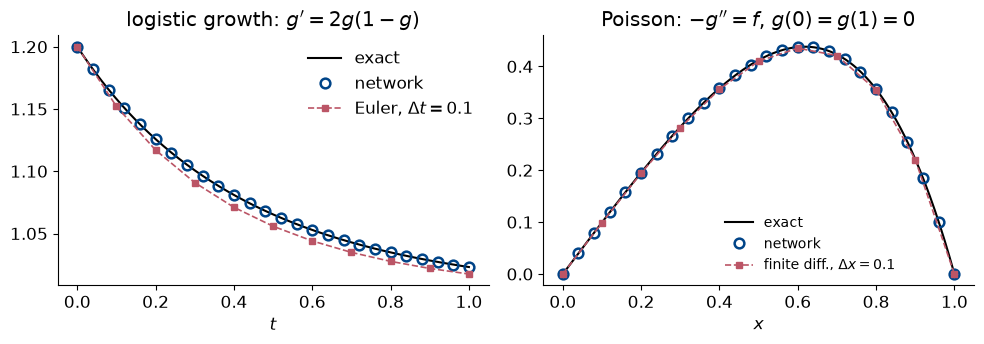

In [14]:
G0_LOG = 1.2


def trial_logistic(layers, X):
    return G0_LOG + X[:, 0] * network(layers, X)


def residual_logistic(layers, X):
    g = trial_logistic(layers, X)
    return d_dxk(trial_logistic, 0)(layers, X) - 2.0 * g * (1 - g)


def trial_poisson(layers, X):
    x = X[:, 0]
    return x * (1 - x) * network(layers, X)


def residual_poisson(layers, X):
    return -d_dxk(d_dxk(trial_poisson, 0), 0)(layers, X) - (3 * X[:, 0] + X[:, 0] ** 2) * jnp.exp(X[:, 0])


exact_logistic = lambda t: G0_LOG / (G0_LOG + (1 - G0_LOG) * np.exp(-2 * t))
exact_poisson = lambda x: x * (1 - x) * np.exp(x)


def euler_logistic(n_steps):
    t = np.linspace(0, 1, n_steps + 1)
    g = np.empty(n_steps + 1)
    g[0] = G0_LOG
    for i in range(n_steps):
        g[i + 1] = g[i] + (1 / n_steps) * 2.0 * g[i] * (1 - g[i])
    return t, g


def fd_poisson(n):
    # -u'' = f with the three-point formula: a tridiagonal system for the n - 1 interior points.
    x = np.linspace(0, 1, n + 1)
    A = (2 * np.eye(n - 1) - np.eye(n - 1, k=1) - np.eye(n - 1, k=-1)) * n ** 2
    u = np.zeros(n + 1)
    u[1:-1] = np.linalg.solve(A, (3 * x[1:-1] + x[1:-1] ** 2) * np.exp(x[1:-1]))
    return x, u


t0 = time.time()
layers_log, _ = solve_de(residual_logistic, [1, 40, 40, 1], np.linspace(0, 1, 50)[:, None], n_iter=3000, gamma=2e-2)
layers_poi, _ = solve_de(residual_poisson, [1, 30, 30, 1], np.linspace(0, 1, 60)[:, None], n_iter=4000, gamma=1e-2)
g_log = np.asarray(trial_logistic(layers_log, jnp.asarray(xx[:, None])))
g_poi = np.asarray(trial_poisson(layers_poi, jnp.asarray(xx[:, None])))
print(f"training both networks: {time.time() - t0:.0f} s\n")
print("logistic growth, max error:")
for n_steps in (10, 100):
    t, ge = euler_logistic(n_steps)
    print(f"  forward Euler, dt = {1 / n_steps:<5}       {np.abs(ge - exact_logistic(t)).max():.1e}")
print(f"  network                        {np.abs(g_log - exact_logistic(xx)).max():.1e}")
print("Poisson, max error:")
for n_int in (10, 100):
    x, u = fd_poisson(n_int)
    print(f"  finite differences, dx = {1 / n_int:<5} {np.abs(u - exact_poisson(x)).max():.1e}")
print(f"  network                        {np.abs(g_poi - exact_poisson(xx)).max():.1e}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
t10, g10 = euler_logistic(10)
ax[0].plot(xx, exact_logistic(xx), color="k", lw=1.5, label="exact")
ax[0].plot(xx[::16], g_log[::16], "o", color=BLUE, ms=7, mfc="none", mew=1.8, label="network")
ax[0].plot(t10, g10, "s--", color=RED, ms=5, lw=1.2, label=r"Euler, $\Delta t=0.1$")
ax[0].set_title("logistic growth: $g'=2g(1-g)$")
ax[0].set_xlabel("$t$")
ax[0].legend(frameon=False)
x10, u10 = fd_poisson(10)
ax[1].plot(xx, exact_poisson(xx), color="k", lw=1.5, label="exact")
ax[1].plot(xx[::16], g_poi[::16], "o", color=BLUE, ms=7, mfc="none", mew=1.8, label="network")
ax[1].plot(x10, u10, "s--", color=RED, ms=5, lw=1.2, label=r"finite diff., $\Delta x=0.1$")
ax[1].set_title("Poisson: $-g''=f$, $g(0)=g(1)=0$")
ax[1].set_xlabel("$x$")
ax[1].legend(frameon=False, loc="lower center", bbox_to_anchor=(0.62, 0.0), fontsize=10)
fig.tight_layout()
show(fig, "v2_ode_results.png")

The network is accurate, but Euler and finite differences take microseconds, while the network needs thousands of training steps. For simple equations like these, the standard methods win.

### A partial differential equation: diffusion

$$\frac{\partial g}{\partial t}=\frac{\partial^2 g}{\partial x^2},\qquad g(0,t)=g(1,t)=0,\qquad g(x,0)=\sin\pi x,$$

with the exact solution $g = e^{-\pi^2 t}\sin\pi x$. The network now has two inputs, $N(x,t)$. One trial solution handles all three conditions:

$$g_t = (1-t)\sin\pi x + x(1-x)\,t\,N(x,t).$$

network: max error 1.0e-02, RMSE 1.8e-03, error at t = 0: 0.0e+00  (3 s)
explicit finite differences, dx = 0.05: max error 1.5e-03


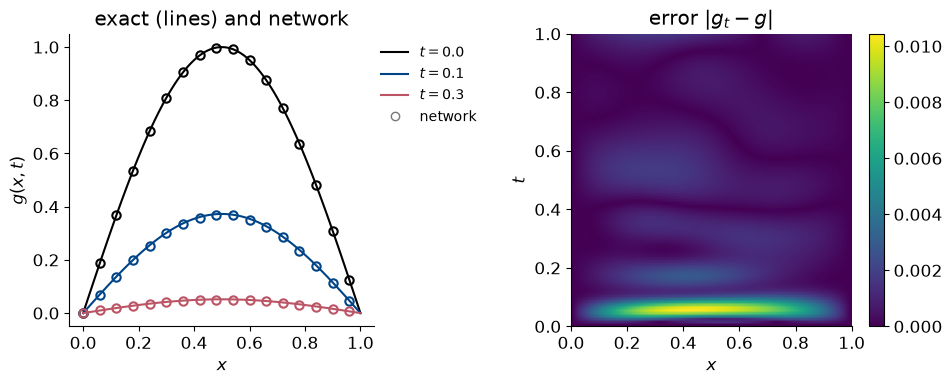

In [15]:
def trial_diffusion(layers, X):
    x, t = X[:, 0], X[:, 1]
    return (1 - t) * jnp.sin(jnp.pi * x) + x * (1 - x) * t * network(layers, X)


def residual_diffusion(layers, X):
    g_t = d_dxk(trial_diffusion, 1)                  # derivative with respect to column 1 (t)
    g_xx = d_dxk(d_dxk(trial_diffusion, 0), 0)       # second derivative with respect to column 0 (x)
    return g_t(layers, X) - g_xx(layers, X)


exact_diffusion = lambda x, t, D=1.0: np.exp(-D * np.pi ** 2 * t) * np.sin(np.pi * x)


def evaluate_diffusion(g_fun, layers, n_eval=101):
    # Errors on a fine grid: max, RMSE, max at t = 0, and the error map.
    xe = np.linspace(0, 1, n_eval)
    Xe, Te = np.meshgrid(xe, xe, indexing="ij")
    g = np.asarray(g_fun(layers, jnp.asarray(np.column_stack([Xe.ravel(), Te.ravel()])))).reshape(n_eval, n_eval)
    err = np.abs(g - exact_diffusion(Xe, Te))
    return {"max": err.max(), "rmse": np.sqrt(np.mean(err ** 2)), "t0": err[:, 0].max(), "map": err, "x": xe, "g": g}


def fd_diffusion(nx=21, alpha=0.5):
    # Explicit finite differences, dt = alpha dx^2 (alpha <= 1/2 for stability), up to t = 1.
    x = np.linspace(0, 1, nx)
    dt = alpha * (x[1] - x[0]) ** 2
    u, t, max_err = np.sin(np.pi * x), 0.0, 0.0
    for _ in range(int(round(1 / dt))):
        u[1:-1] = u[1:-1] + alpha * (u[2:] - 2 * u[1:-1] + u[:-2])
        t += dt
        max_err = max(max_err, np.abs(u - exact_diffusion(x, t)).max())
    return max_err


t0 = time.time()
xs = np.linspace(0, 1, 20)
Xg, Tg = np.meshgrid(xs, xs, indexing="ij")
X_col = np.column_stack([Xg.ravel(), Tg.ravel()])           # 20 x 20 collocation points
layers_diff, _ = solve_de(residual_diffusion, [2, 30, 30, 1], X_col, n_iter=800, gamma=1e-2)
hard = evaluate_diffusion(trial_diffusion, layers_diff)
print(f"network: max error {hard['max']:.1e}, RMSE {hard['rmse']:.1e}, error at t = 0: {hard['t0']:.1e}  "
      f"({time.time() - t0:.0f} s)")
print(f"explicit finite differences, dx = 0.05: max error {fd_diffusion():.1e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.15], "wspace": 0.6})
for ts, col in zip((0.0, 0.1, 0.3), ("k", BLUE, RED)):
    it = int(round(ts * 100))
    ax[0].plot(hard["x"], exact_diffusion(hard["x"], ts), color=col, lw=1.5, label=f"$t={ts:.1f}$")
    ax[0].plot(hard["x"][::6], hard["g"][::6, it], "o", color=col, ms=6, mfc="none", mew=1.5)
ax[0].plot([], [], "o", color=GREY, mfc="none", label="network")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$g(x,t)$")
ax[0].set_title("exact (lines) and network")
ax[0].legend(frameon=False, fontsize=10, loc="upper left", bbox_to_anchor=(0.98, 1.0))
im = ax[1].imshow(hard["map"].T, origin="lower", extent=[0, 1, 0, 1], aspect="auto", cmap="viridis")
fig.colorbar(im, ax=ax[1])
ax[1].set_xlabel("$x$")
ax[1].set_ylabel("$t$")
ax[1].set_title("error $|g_t-g|$")
show(fig, "v2_diffusion.png")

The error is exactly zero on the three edges, because the conditions are built into $g_t$. It is largest near $t=0$, where the solution changes fastest.

### Soft constraints: physics-informed neural networks (PINNs)

Instead of building $g_t$ by hand, we let the network *be* the solution, $u\approx N(x,t)$, and add the conditions to the cost as penalties:

$$L = L_\mathrm{PDE} + \lambda\,(L_\mathrm{IC} + L_\mathrm{BC}).$$

The PDE term uses points inside the domain, $L_\mathrm{IC}$ points on $t=0$, and $L_\mathrm{BC}$ points on $x=0$ and $x=1$.

In [16]:
def u_net(layers, X):
    return network(layers, X)


u_t = d_dxk(u_net, 1)
u_xx = d_dxk(d_dxk(u_net, 0), 0)

X_int = jnp.asarray(np.column_stack([Xg[1:-1, 1:-1].ravel(), Tg[1:-1, 1:-1].ravel()]))   # 18 x 18 interior points
X_ic = jnp.asarray(np.column_stack([xs, np.zeros(20)]))                                  # t = 0
X_left = jnp.asarray(np.column_stack([np.zeros(20), xs]))                                # x = 0
X_right = jnp.asarray(np.column_stack([np.ones(20), xs]))                                # x = 1


def pinn_cost(layers, lam=10.0):
    L_pde = jnp.mean((u_t(layers, X_int) - u_xx(layers, X_int)) ** 2)
    L_ic = jnp.mean((u_net(layers, X_ic) - jnp.sin(jnp.pi * X_ic[:, 0])) ** 2)
    L_bc = jnp.mean(u_net(layers, X_left) ** 2) + jnp.mean(u_net(layers, X_right) ** 2)
    return L_pde + lam * (L_ic + L_bc)


t0 = time.time()
layers_pinn, _ = adam_minimise(pinn_cost, to_jax(create_layers([2, 30, 30, 1], "tanh", np.random.default_rng(1))),
                               n_iter=4000, gamma=1e-2)
soft = evaluate_diffusion(u_net, layers_pinn)
print(f"({time.time() - t0:.0f} s)\n")
print(f"{'':22s}{'RMSE':>10s}{'error at t=0':>15s}")
print(f"{'hard (trial solution)':22s}{hard['rmse']:10.1e}{hard['t0']:15.1e}")
print(f"{'soft, lambda = 10':22s}{soft['rmse']:10.1e}{soft['t0']:15.1e}")

(8 s)

                            RMSE   error at t=0
hard (trial solution)    1.8e-03        0.0e+00
soft, lambda = 10        6.5e-03        6.3e-03


If you *can* build a trial solution, do: it is exact on the boundary and more accurate. Soft constraints are flexible, but the conditions only hold approximately, and $\lambda$ must be tuned.

*Try it:* change $\lambda$ to 1 or 100 in `pinn_cost` (e.g. `lambda L: pinn_cost(L, lam=100.0)`). What happens to the error at $t=0$, and to the error inside the domain?

### Why soft constraints at all? Inverse problems

Now the diffusion coefficient in $\partial_t u = D\,\partial_x^2 u$ is **unknown**. We have no initial or boundary conditions, only 40 noisy measurements of the solution (made with the true $D=0.5$). We treat $D$ as one more trainable parameter:

$$L(N, D) = \frac1n\sum_j\big(\partial_t N - D\,\partial_x^2 N\big)_j^2 + \lambda\,\frac1{40}\sum_i\big(N(x_i,t_i) - y_i\big)^2 .$$

No trial solution is possible here, so soft constraints are the only option.

start D = 2.0:  recovered D = 0.5133


start D = 1.0:  recovered D = 0.5148


start D = 0.1:  recovered D = 0.5124


five times more noise:  recovered D = 0.6901  (29 s)


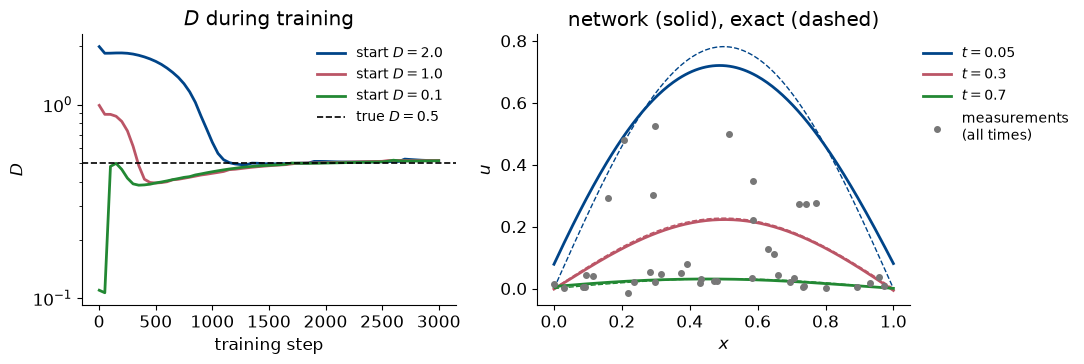

In [17]:
D_TRUE = 0.5


def measurements(n_obs=40, noise=0.01, seed=3):
    rng = np.random.default_rng(seed)
    X_obs = np.column_stack([rng.uniform(0, 1, n_obs), rng.uniform(0, 1, n_obs)])
    y_obs = exact_diffusion(X_obs[:, 0], X_obs[:, 1], D_TRUE) + rng.normal(0, noise, n_obs)
    return jnp.asarray(X_obs), jnp.asarray(y_obs)


def find_D(X_obs, y_obs, D0=2.0, n_iter=3000, lam=10.0):
    params = (to_jax(create_layers([2, 30, 30, 1], "tanh", np.random.default_rng(1))), jnp.array(D0))

    def cost_fn(params):
        layers, D = params
        return (jnp.mean((u_t(layers, X_int) - D * u_xx(layers, X_int)) ** 2)
                + lam * jnp.mean((u_net(layers, X_obs) - y_obs) ** 2))

    return adam_minimise(cost_fn, params, n_iter=n_iter, gamma=1e-2, trace_fn=lambda p: p[1])


t0 = time.time()
X_obs, y_obs = measurements()
runs = []
for D0 in (2.0, 1.0, 0.1):
    params, trace = find_D(X_obs, y_obs, D0=D0)
    runs.append((D0, params, trace))
    print(f"start D = {D0}:  recovered D = {float(params[1]):.4f}")
params5, _ = find_D(*measurements(noise=0.05))
print(f"five times more noise:  recovered D = {float(params5[1]):.4f}  ({time.time() - t0:.0f} s)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for (D0, params, trace), col in zip(runs, (BLUE, RED, GREEN)):
    ax[0].plot(trace[:, 0], trace[:, 2], color=col, lw=2, label=f"start $D={D0}$")
ax[0].axhline(D_TRUE, color="k", lw=1.2, ls="--", label="true $D=0.5$")
ax[0].set_xlabel("training step")
ax[0].set_ylabel("$D$")
ax[0].set_yscale("log")
ax[0].set_title("$D$ during training")
ax[0].legend(frameon=False, fontsize=10)
layers_inv = runs[0][1][0]
x = np.linspace(0, 1, 200)
for ts, col in zip((0.05, 0.3, 0.7), (BLUE, RED, GREEN)):
    ax[1].plot(x, np.asarray(u_net(layers_inv, jnp.asarray(np.column_stack([x, np.full_like(x, ts)])))),
               color=col, lw=2, label=f"$t={ts}$")
    ax[1].plot(x, exact_diffusion(x, ts, D_TRUE), color=col, lw=1, ls="--")
ax[1].scatter(np.asarray(X_obs)[:, 0], np.asarray(y_obs), color=GREY, s=16, zorder=3, label="measurements\n(all times)")
ax[1].set_xlabel("$x$")
ax[1].set_ylabel("$u$")
ax[1].set_title("network (solid), exact (dashed)")
ax[1].legend(frameon=False, fontsize=10, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
show(fig, "v2_pinn_inverse.png")

All three starting guesses end close to the true value. But with five times more noise the recovered $D$ is far off: inverse problems are sensitive to noise, so a recovered parameter needs an error bar (for example, from the bootstrap).

## Summary

- **Backpropagation** is the chain rule: compute the errors $\delta^l$ from the output backwards. Always check your gradient against `jax.grad`.
- **Activation functions** must be non-linear, and training only sees $f'$. **Initialise** with variance $1/M$ (tanh, sigmoid) or $2/M$ (ReLU).
- **Output activation and cost come in pairs**, and then $\delta^L = a - y$.
- **Universal approximation:** a wide enough network can represent any continuous function. A ReLU network does it with kinks.
- **Differential equations:** the residual is the cost. Conditions go into the trial solution (hard) or the cost (soft). Use smooth activations. The method is flexible, but slower than standard methods, and without their guarantees.